# Домашнее задание к занятию "Улучшение качества обучения нейросети"

## Задание

На примере датасета персонажей мультфильма Симпсонов:

1. Модифицируйте код обучения, используя различные типы LR Schedulers из Pytorch. Проведите минимум 2 эксперимента с разными шедулерами.
1. Подберите аугментации **train** данных, при которых итоговое качество на валидации станет сильно **хуже**, чем полученное на занятии.
1. Возьмите любую архитектуру (VGG, EfficientNet или MobileNet) и примените к ней методы, которые разбирались на занятии.
1. Оформите вывод по результатам проведённых экспериментов.

In [58]:
import os
import time
import glob
import kaggle
from collections import Counter
import pandas as pd
from pathlib import Path

from tqdm.notebook import tqdm
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
from torch import nn
import torch.nn.functional as F
from torchsummary import summary
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import Subset

## Загрузка и подготовка данных

### Загрузка данных с Kaggle

In [60]:
kaggle.api.authenticate()

kaggle.api.dataset_download_files(
    "alexattia/the-simpsons-characters-dataset",
    path='datas/simpsons',
    unzip=True
)

Dataset URL: https://www.kaggle.com/datasets/alexattia/the-simpsons-characters-dataset


>**Внимание!** После распаковки архива по какой-то неведомой мне причине внутри папки `sympsons_dataset` создается ее дубль

### Подготовка датасетов

Трансформация данных

In [61]:
input_size = 224

train_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ColorJitter(0.9, 0.9, 0.9),
    transforms.RandomAffine(5),
    transforms.ToTensor(),
])


val_transform = transforms.Compose([
    transforms.Resize(input_size),
    transforms.CenterCrop(input_size),
    transforms.ToTensor(),
])

Датасеты

In [62]:
data_dir = "datas/simpsons/simpsons_dataset"

full_dataset = datasets.ImageFolder(root=data_dir)
indices = list(range(len(full_dataset)))
train_indices, val_indices = train_test_split(
    indices, 
    test_size=0.3, 
    stratify=full_dataset.targets, # Стратификация по меткам из датасета
    random_state=42
)

train_dataset = datasets.ImageFolder(root=data_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)

train_dataset = Subset(train_dataset, train_indices)
val_dataset = Subset(val_dataset, val_indices)

print(f"Тренировочный сет: {len(train_dataset)} картинок")
print(f"Валидационный сет: {len(val_dataset)} картинок")

Тренировочный сет: 14653 картинок
Валидационный сет: 6280 картинок


EDA

In [66]:
print(f"Найдено классов: {len(full_dataset.classes)}")
print(f"Первые 5 классов: {full_dataset.classes[:5]}")

Найдено классов: 42
Первые 5 классов: ['abraham_grampa_simpson', 'agnes_skinner', 'apu_nahasapeemapetilon', 'barney_gumble', 'bart_simpson']


             name  count
15  homer_simpson   2246
28   ned_flanders   1454
27    moe_szyslak   1452
20   lisa_simpson   1354
4    bart_simpson   1342


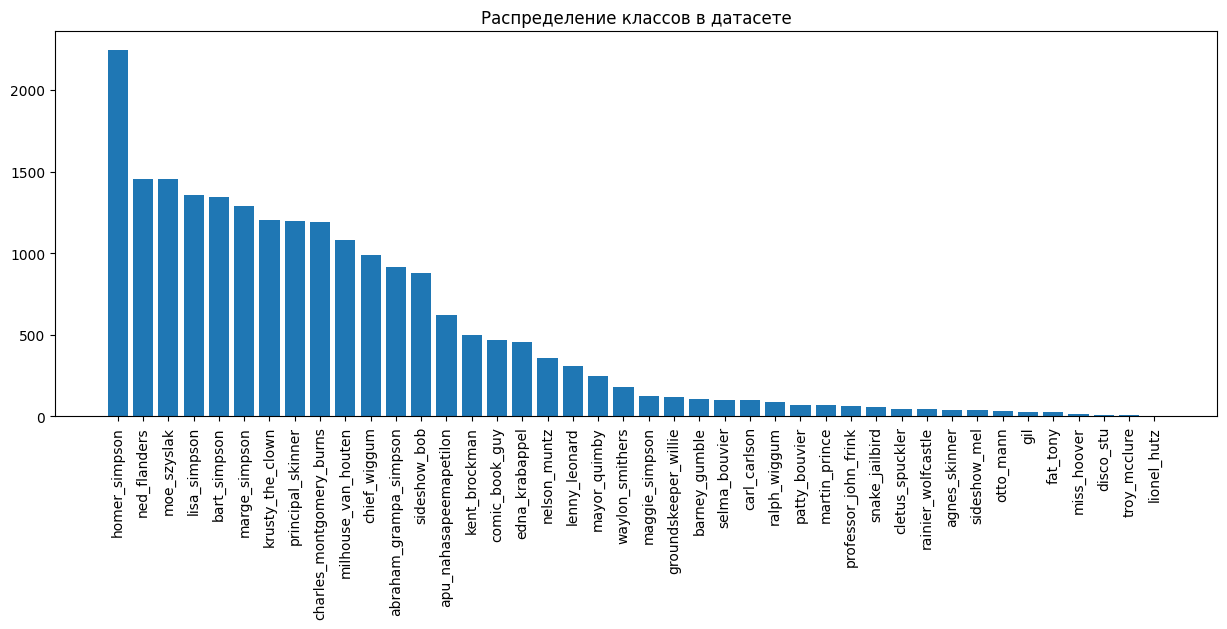

In [64]:
# Считаем количество картинок в каждом классе
count_dict = Counter([label for _, label in full_dataset.samples])

# Создаем таблицу для наглядности, сопоставляя индекс с названием
data = [
    {'name': full_dataset.classes[idx], 'count': count} 
    for idx, count in count_dict.items()
]
df = pd.DataFrame(data).sort_values('count', ascending=False)

print(df.head()) # Посмотрим на топ-5 самых частых героев

# Визуализируем
plt.figure(figsize=(15, 5))
plt.bar(df['name'], df['count'])
plt.xticks(rotation=90)
plt.title('Распределение классов в датасете')
plt.show()

Итераторы

In [68]:
BATCH_SIZE = 64 

train_loader = torch.utils.data.DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = torch.utils.data.DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

# Проверим один батч
images, labels = next(iter(train_loader))
print(f"Форма тензора с картинками: {images.shape}")
print(f"Форма тензора с метками: {labels.shape}")

Форма тензора с картинками: torch.Size([64, 3, 224, 224])
Форма тензора с метками: torch.Size([64])


## 1. LR Schedulers

## 2. Аугментация

## 3. MobileNet

## 4. Выводы